# Challenge 2: Object Detection with Feature Point Matching

**Course**: CI 7306 Image Analytics / CI 7204 Image Processing and Analytics  
**Instructor**: Assoc.Prof.Thitirat Siriborvornratanakul, Ph.D.  
**Semester**: 2/2568

---

## Overview

This report presents object detection results using **Feature Point Matching** — a traditional (non-ML) computer vision technique.  
The pipeline detects and describes local keypoints in a template image, then matches them against each video frame to localize the object.

### Techniques Used
- **Feature Detector/Descriptor**: SIFT (Scale-Invariant Feature Transform)
- **Matching**: FLANN-based matcher with Lowe's ratio test
- **Localization**: Homography estimation with RANSAC + perspective transform
- **Preprocessing**: Grayscale conversion + CLAHE (Contrast Limited Adaptive Histogram Equalization)

### Case Summary
| Category | Count | Expected Outcome |
|---|---|---|
| Easy Success | 5 | Detection works smoothly |
| Difficult Success | 5 | Detection works despite one challenge |
| Expected Fail | 5 | Known to fail (no features on object) |
| Unexpected Fail | 5 | Surprising failure despite appearing feasible |

---
## Part 0: Setup and Imports

In [102]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from IPython.display import display, HTML, Video

from src.pipeline   import ObjectDetectionPipeline
from src.detector   import get_detector
from src.utils      import preprocess, summarize_results
from cases_config   import CASES, get_case, get_cases_by_category

# ─── Display helpers ───────────────────────────────────────────────────────────

def show_bgr(img, title='', figsize=(6, 4), ax=None):
    """Display a BGR OpenCV image in matplotlib."""
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(rgb)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    return ax

def show_keypoints(img_path, detector_name='sift', use_clahe=True, figsize=(8, 5)):
    """Show template with detected keypoints overlaid."""
    img  = cv2.imread(img_path)
    gray = preprocess(img, use_clahe=use_clahe)
    det  = get_detector(detector_name)
    kps, _ = det.detectAndCompute(gray, None)
    vis  = cv2.drawKeypoints(img, kps, None, color=(0, 255, 0),
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    show_bgr(img, title='Template', ax=axes[0])
    show_bgr(vis, title=f'Keypoints ({len(kps)}) – {detector_name.upper()}', ax=axes[1])
    plt.tight_layout()
    plt.show()
    return len(kps)

def plot_matches_per_frame(results, title='Good Matches per Frame', figsize=(10, 3)):
    """Bar chart of good match count per frame."""
    frames  = range(len(results))
    matches = [r['num_good_matches'] for r in results]
    found   = [r['found'] for r in results]
    colors  = ['green' if f else 'red' for f in found]
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(frames, matches, color=colors, width=1.0, linewidth=0)
    ax.set_xlabel('Frame Index')
    ax.set_ylabel('Good Matches')
    ax.set_title(title)
    green_p = mpatches.Patch(color='green', label='Detected')
    red_p   = mpatches.Patch(color='red',   label='Not Detected')
    ax.legend(handles=[green_p, red_p], loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_inliers_per_frame(results, title='RANSAC Inliers per Frame', figsize=(10, 3)):
    """Line chart of inlier count per frame."""
    frames  = range(len(results))
    inliers = [r['inlier_count'] for r in results]
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(frames, inliers, color='steelblue', linewidth=1)
    ax.fill_between(frames, inliers, alpha=0.2, color='steelblue')
    ax.set_xlabel('Frame Index')
    ax.set_ylabel('Inlier Count')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def show_sample_frame(video_path, frame_idx=30):
    """Extract and display a single frame from a video."""
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    return frame if ret else None

print('Setup complete. OpenCV version:', cv2.__version__)

Setup complete. OpenCV version: 4.13.0


---
## Part 1: Method Description

### 1.1 Algorithm Overview

The detection pipeline follows these steps:

```
TEMPLATE (once at init):
  BGR → Grayscale → CLAHE → SIFT.detectAndCompute → {kp_template, des_template}

PER FRAME:
  BGR → Grayscale → CLAHE → SIFT.detectAndCompute → {kp_frame, des_frame}
      → FlannMatcher.knnMatch(k=2) → Lowe ratio test → {good_matches}
      → findHomography(RANSAC) → H (3×3)
      → perspectiveTransform(corners) → bounding polygon on frame
```

### 1.2 SIFT (Scale-Invariant Feature Transform)

SIFT detects and describes local image regions that are invariant to:
- **Scale**: by finding extrema in a Gaussian scale-space pyramid
- **Rotation**: by assigning a dominant gradient orientation
- **Illumination**: by operating on gradient magnitudes (not absolute intensities)

Each keypoint is described by a **128-dimensional float vector** encoding the local gradient distribution in a 4×4 grid of 8-bin histograms.

### 1.3 CLAHE Preprocessing

**Contrast Limited Adaptive Histogram Equalization** (`cv2.createCLAHE`) improves local contrast before feature detection.  
This helps in uneven lighting (e.g., bright spots, shadow edges) by redistributing intensity in small tiles rather than globally.  
**Critical**: the same CLAHE parameters are applied to both template and frame so descriptors remain comparable.

### 1.4 FLANN Matcher + Lowe's Ratio Test

FLANN (`cv2.FlannBasedMatcher`) with a KD-tree index efficiently finds the **2 nearest neighbors** for each template descriptor in the frame descriptor space.

**Lowe's ratio test** (from SIFT paper, 2004): keep match `m` only if `m.distance < ratio × n.distance`  
where `n` is the second-nearest neighbor. This rejects ambiguous matches where the best match is not clearly better than the second-best.

### 1.5 RANSAC Homography

`cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, threshold)` estimates the **3×3 perspective transformation** matrix `H` that maps template coordinates to frame coordinates, while robustly handling outlier matches.

The number of **inliers** (matches consistent with H within the reprojection threshold) is a key quality metric.

### 1.6 Bounding Box Projection

`cv2.perspectiveTransform` maps the 4 corners of the template rectangle through `H` to get the projected quadrilateral in the frame.  
A validation step (area, convexity, determinant checks) filters out geometrically degenerate homographies.

---
## Part 2: Easy Success Cases (e1 – e5)

High-texture flat objects under good lighting with minimal motion.  
SIFT finds 500+ keypoints on the template; hundreds of matches per frame.

Case e1: Book Cover – Frontal Steady
Difficulty notes: High-texture flat object (book cover). SIFT finds many stable keypoints. Camera held steady; gentle 5–10° tilt over 10 seconds.



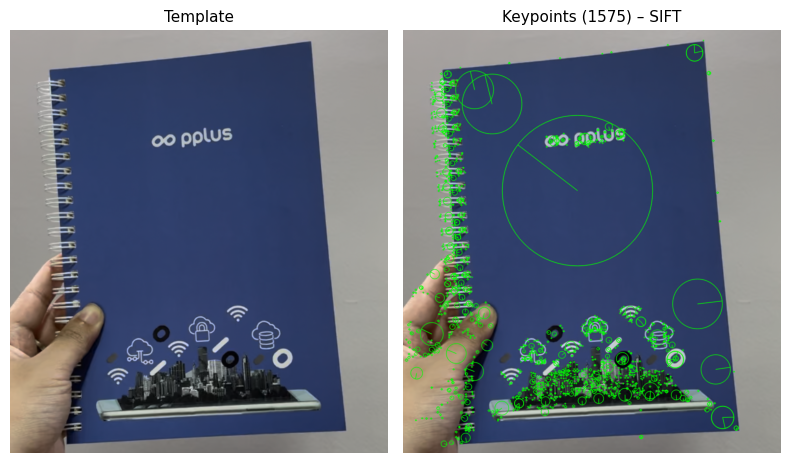

[Pipeline] Template 'template_e1.jpg': 1575 keypoints detected (SIFT)
  Frame    0: FOUND | matches=816 | inliers=726
  Frame   30: FOUND | matches=382 | inliers=301
  Frame   60: FOUND | matches=409 | inliers=329
  Frame   90: FOUND | matches=477 | inliers=372
  Frame  120: FOUND | matches=429 | inliers=333
  Frame  150: FOUND | matches=408 | inliers=327
  Frame  180: FOUND | matches=487 | inliers=388

[Summary] videos/easy/video_e1.mp4
  Total frames    : 185
  Detected frames : 185
  Detection rate  : 100.0%
  Avg good matches: 472.2
  Avg inliers     : 375.0
  Output saved to : outputs/easy/output_e1.mp4


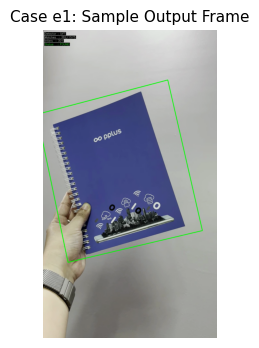

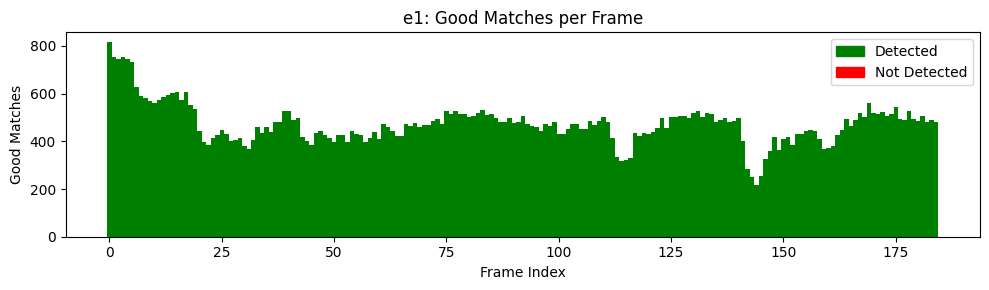

In [105]:
# ── Easy Case e1 ──────────────────────────────────────────────────────────────
case = get_case('e1')
print(f"Case e1: {case['label']}")
print(f"Difficulty notes: {case['difficulty_notes']}\n")

# Show keypoints on template
n_kp = show_keypoints(case['template'], detector_name=case['detector'])

# Run pipeline
pipeline_e1 = ObjectDetectionPipeline(
    template_path=case['template'], detector_name=case['detector'],
    ratio=case['ratio'], min_matches=case['min_matches'],
    min_inliers=case['min_inliers'], use_clahe=case['use_clahe']
)
results_e1 = pipeline_e1.run_on_video(
    case['video'], output_path=case['output'], verbose=True
)

# Show sample output frame
frame_e1 = show_sample_frame(case['output'], frame_idx=30)
if frame_e1 is not None:
    show_bgr(frame_e1, title='Case e1: Sample Output Frame')
    plt.show()

# Charts
plot_matches_per_frame(results_e1, title='e1: Good Matches per Frame')

Case e2: Printed A4 Poster – Slow Pan


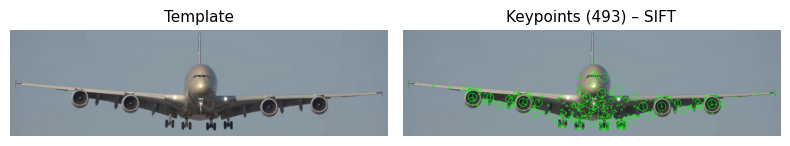

[Pipeline] Template 'template_e2.jpg': 493 keypoints detected (SIFT)
  Frame    0: FOUND | matches=200 | inliers=151
  Frame   30: FOUND | matches=200 | inliers=162
  Frame   60: FOUND | matches=247 | inliers=208
  Frame   90: FOUND | matches=228 | inliers=196
  Frame  120: FOUND | matches=210 | inliers=153

[Summary] videos/easy/video_e2.mp4
  Total frames    : 128
  Detected frames : 128
  Detection rate  : 100.0%
  Avg good matches: 219.5
  Avg inliers     : 181.2
  Output saved to : outputs/easy/output_e2.mp4


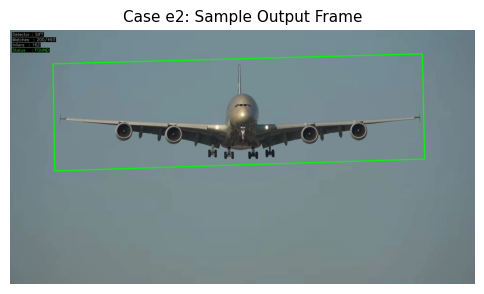

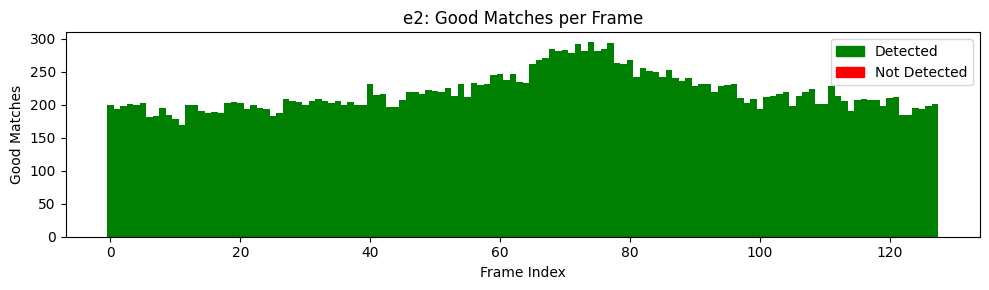

In [106]:
# ── Easy Case e2 ──────────────────────────────────────────────────────────────
case = get_case('e2')
print(f"Case e2: {case['label']}")
n_kp = show_keypoints(case['template'], detector_name=case['detector'])
pipeline_e2 = ObjectDetectionPipeline(
    template_path=case['template'], detector_name=case['detector'],
    ratio=case['ratio'], min_matches=case['min_matches'],
    min_inliers=case['min_inliers'], use_clahe=case['use_clahe']
)
results_e2 = pipeline_e2.run_on_video(case['video'], output_path=case['output'], verbose=True)
frame_e2 = show_sample_frame(case['output'], 30)
if frame_e2 is not None: show_bgr(frame_e2, 'Case e2: Sample Output Frame'); plt.show()
plot_matches_per_frame(results_e2, 'e2: Good Matches per Frame')

Case e3: Cereal Box Front – Static Camera


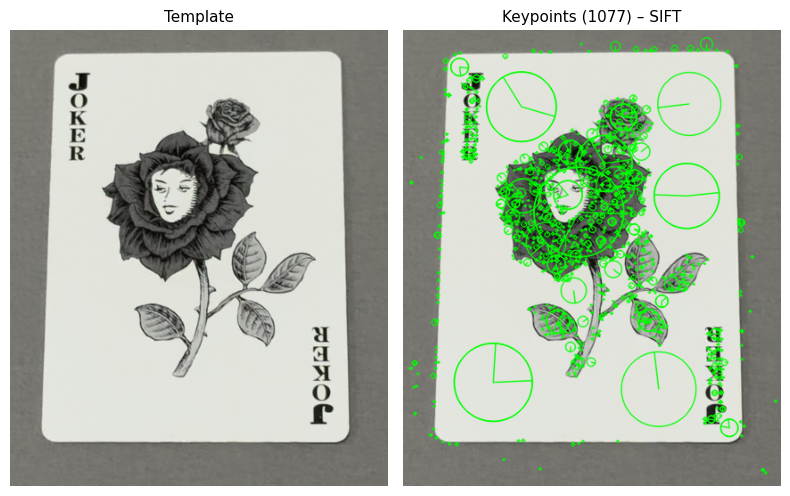

[Pipeline] Template 'template_e3.jpg': 1077 keypoints detected (SIFT)
  Frame    0: FOUND | matches=653 | inliers=615
  Frame   30: FOUND | matches=466 | inliers=427
  Frame   60: FOUND | matches=454 | inliers=414
  Frame   90: FOUND | matches=465 | inliers=418
  Frame  120: FOUND | matches=462 | inliers=412

[Summary] videos/easy/video_e3.mp4
  Total frames    : 149
  Detected frames : 149
  Detection rate  : 100.0%
  Avg good matches: 475.4
  Avg inliers     : 428.7
  Output saved to : outputs/easy/output_e3.mp4


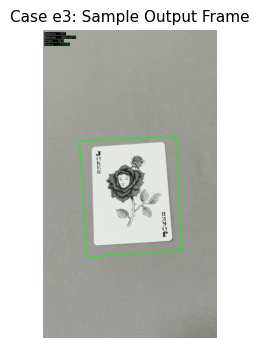

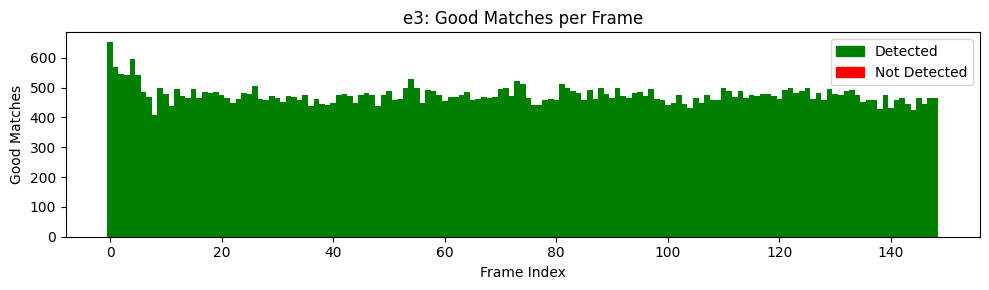

In [115]:
# ── Easy Case e3 ──────────────────────────────────────────────────────────────
case = get_case('e3')
print(f"Case e3: {case['label']}")
n_kp = show_keypoints(case['template'], detector_name=case['detector'])
pipeline_e3 = ObjectDetectionPipeline(
    template_path=case['template'], detector_name=case['detector'],
    ratio=case['ratio'], min_matches=case['min_matches'],
    min_inliers=case['min_inliers'], use_clahe=case['use_clahe']
)
results_e3 = pipeline_e3.run_on_video(case['video'], output_path=case['output'], verbose=True)
frame_e3 = show_sample_frame(case['output'], 30)
if frame_e3 is not None: show_bgr(frame_e3, 'Case e3: Sample Output Frame'); plt.show()
plot_matches_per_frame(results_e3, 'e3: Good Matches per Frame')

Case e4: Magazine Cover – Frontal, Well-lit


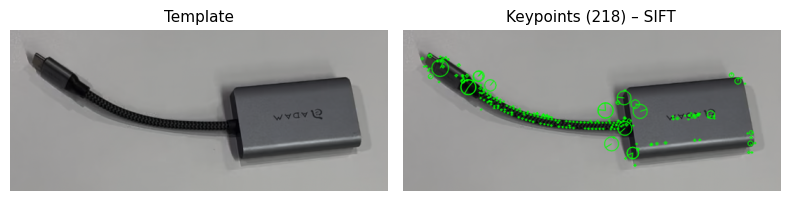

[Pipeline] Template 'template_e4.jpg': 218 keypoints detected (SIFT)
  Frame    0: FOUND | matches=90 | inliers=83
  Frame   30: FOUND | matches=65 | inliers=55
  Frame   60: FOUND | matches=45 | inliers=39
  Frame   90: FOUND | matches=52 | inliers=46
  Frame  120: FOUND | matches=54 | inliers=46

[Summary] videos/easy/video_e4.mp4
  Total frames    : 126
  Detected frames : 126
  Detection rate  : 100.0%
  Avg good matches: 57.5
  Avg inliers     : 48.8
  Output saved to : outputs/easy/output_e4.mp4


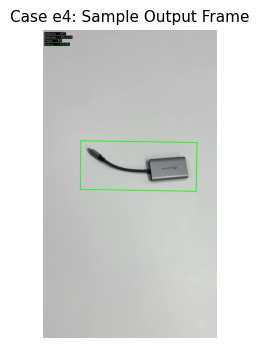

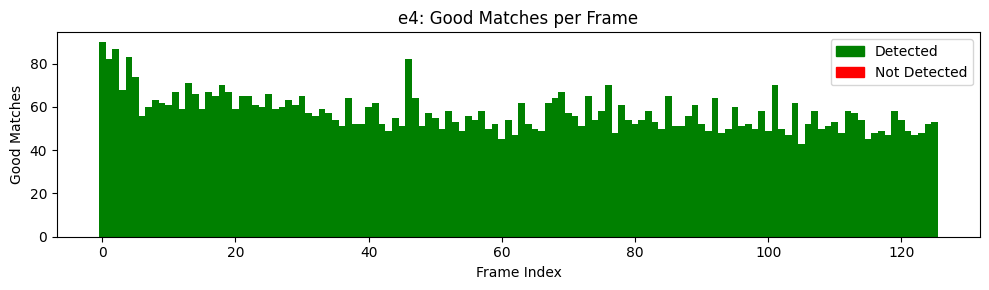

In [ ]:
# ── Easy Case e4 ──────────────────────────────────────────────────────────────
case = get_case('e4')
print(f"Case e4: {case['label']}")
n_kp = show_keypoints(case['template'], detector_name=case['detector'])
# pipeline_e4 = ObjectDetectionPipeline(
#     template_path=case['template'], detector_name=case['detector'],
#     ratio=case['ratio'], min_matches=case['min_matches'],
#     min_inliers=case['min_inliers'], use_clahe=case['use_clahe']
# )
# results_e4 = pipeline_e4.run_on_video(case['video'], output_path=case['output'], verbose=True)
# frame_e4 = show_sample_frame(case['output'], 30)
# if frame_e4 is not None: show_bgr(frame_e4, 'Case e4: Sample Output Frame'); plt.show()
# plot_matches_per_frame(results_e4, 'e4: Good Matches per Frame')

Case e5: Playing Card (Face Card) – Overhead


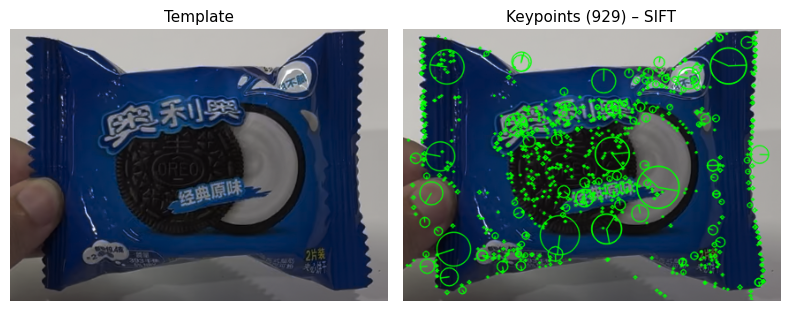

[Pipeline] Template 'template_e5.jpg': 929 keypoints detected (SIFT)
  Frame    0: FOUND | matches=500 | inliers=480
  Frame   30: FOUND | matches=246 | inliers=163
  Frame   60: FOUND | matches=317 | inliers=293
  Frame   90: FOUND | matches=110 | inliers=83
  Frame  120: FOUND | matches=275 | inliers=220
  Frame  150: FOUND | matches=271 | inliers=236
  Frame  180: FOUND | matches=229 | inliers=185

[Summary] videos/easy/video_e5.mp4
  Total frames    : 195
  Detected frames : 195
  Detection rate  : 100.0%
  Avg good matches: 247.2
  Avg inliers     : 207.2
  Output saved to : outputs/easy/output_e5.mp4


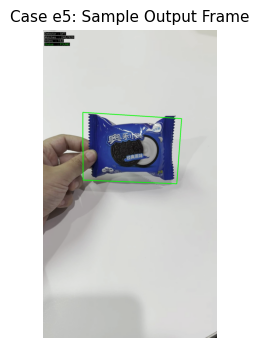

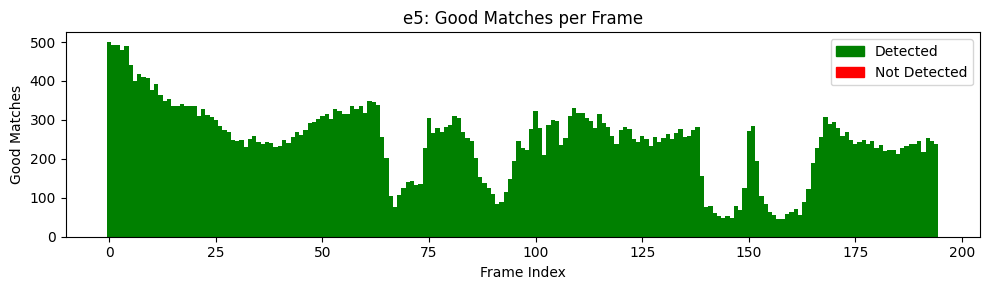

In [116]:
# ── Easy Case e5 ──────────────────────────────────────────────────────────────
case = get_case('e5')
print(f"Case e5: {case['label']}")
n_kp = show_keypoints(case['template'], detector_name=case['detector'])
pipeline_e5 = ObjectDetectionPipeline(
    template_path=case['template'], detector_name=case['detector'],
    ratio=case['ratio'], min_matches=case['min_matches'],
    min_inliers=case['min_inliers'], use_clahe=case['use_clahe']
)
results_e5 = pipeline_e5.run_on_video(case['video'], output_path=case['output'], verbose=True)
frame_e5 = show_sample_frame(case['output'], 30)
if frame_e5 is not None: show_bgr(frame_e5, 'Case e5: Sample Output Frame'); plt.show()
plot_matches_per_frame(results_e5, 'e5: Good Matches per Frame')

---
## Part 3: Difficult Success Cases (d1 – d5)

Each case introduces **one specific challenge** that vanilla SIFT would struggle with.  
To overcome each challenge, additional **traditional image processing techniques** from the course are applied *before or alongside* the pipeline.  
Detection still succeeds — but only because of those targeted techniques.

| Case | Challenge | Curriculum Techniques Applied |
|---|---|---|
| **d1** | ~35% hand occlusion | Class 06 – Morphological Gradient; Class 04 – Threshold; Class 08 – SIFT `contrastThreshold` tuning |
| **d2** | Warm/yellow illumination shift | Class 04 – LAB colour space (L channel); Class 07 – Histogram comparison + CLAHE normalisation |
| **d3** | Large viewing angle 50–60° | Class 03 – Bilateral filter; Class 05 – Canny edge density; Class 08 – SIFT vs AKAZE comparison |
| **d4** | Slight spine bend (non-planar) | Class 03 – GaussianBlur; Class 05 – Sobel gradient map + per-row analysis; Class 08 – relaxed RANSAC |
| **d5** | Specular glare / reflection | Class 04 – Threshold glare mask; Class 07 – Histogram stretching (LUT) + strong CLAHE |

In [ ]:
# ── Difficult Cases d1–d5 ─────────────────────────────────────────────────────
difficult_results = {}

for cid in ['d1', 'd2', 'd3', 'd4', 'd5']:
    case = get_case(cid)
    print(f"\n{'='*55}")
    print(f"Case {cid}: {case['label']}")
    print(f"Challenge: {case['difficulty_notes'][:120]}...")

    p = ObjectDetectionPipeline(
        template_path=case['template'], detector_name=case['detector'],
        ratio=case['ratio'], min_matches=case['min_matches'],
        min_inliers=case['min_inliers'], ransac_thresh=case['ransac_thresh'],
        use_clahe=case['use_clahe']
    )
    res = p.run_on_video(case['video'], output_path=case['output'], verbose=True)
    difficult_results[cid] = res

    # Show inlier timeline (shows stability over time)
    plot_inliers_per_frame(res, f'{cid}: RANSAC Inliers per Frame (challenge: {case["label"]})')

---
## Part 4A: Expected Fail Cases (f1 – f5)

These objects **lack feature-detectable texture**.  
SIFT/ORB find near-zero keypoints on the template itself; matching is impossible.

In [ ]:
# ── Expected Fail Cases f1–f5 ─────────────────────────────────────────────────
fail_results = {}

for cid in ['f1', 'f2', 'f3', 'f4', 'f5']:
    case = get_case(cid)
    print(f"\n{'='*55}")
    print(f"Case {cid}: {case['label']}")
    print(f"Failure mode: {case['difficulty_notes'][:150]}...")

    # Show keypoints on template (expected: very few)
    print("  Template keypoint count:")
    n_kp = show_keypoints(case['template'], detector_name=case['detector'])
    print(f"  → {n_kp} keypoints detected")

    try:
        p = ObjectDetectionPipeline(
            template_path=case['template'], detector_name=case['detector'],
            ratio=case['ratio'], min_matches=case['min_matches'],
            min_inliers=case['min_inliers'], use_clahe=case['use_clahe']
        )
        res = p.run_on_video(case['video'], output_path=case['output'], verbose=False)
        fail_results[cid] = res
        summary = summarize_results(res)
        print(f"  Detection rate: {summary['detection_rate']*100:.1f}% "
              f"(avg matches: {summary['avg_good_matches']:.1f})")
        plot_matches_per_frame(res, f'{cid}: Matches per Frame (expected near-zero)')
    except ValueError as e:
        print(f"  Pipeline init failed (as expected): {e}")
        print(f"  → Template has no keypoints; pipeline cannot be constructed.")

---
## Part 4B: Unexpected Fail Cases (u1 – u5)

Objects that *appear* similar to easy cases but fail due to a subtle factor.  
These are the most instructive cases for understanding the **limitations** of feature-point matching.

In [ ]:
# ── Unexpected Fail Cases u1–u5 ─────────────────────────────────────────────────
unexpected_fail_results = {}

for cid in ['u1', 'u2', 'u3', 'u4', 'u5']:
    case = get_case(cid)
    print(f"\n{'='*55}")
    print(f"Case {cid}: {case['label']}")
    print(f"Failure mode: {case['difficulty_notes'][:150]}...")

    # Show keypoints on template (expected: very few)
    print("  Template keypoint count:")
    n_kp = show_keypoints(case['template'], detector_name=case['detector'])
    print(f"  → {n_kp} keypoints detected")

    try:
        p = ObjectDetectionPipeline(
            template_path=case['template'], detector_name=case['detector'],
            ratio=case['ratio'], min_matches=case['min_matches'],
            min_inliers=case['min_inliers'], use_clahe=case['use_clahe']
        )
        res = p.run_on_video(case['video'], output_path=case['output'], verbose=False)
        unexpected_fail_results[cid] = res
        summary = summarize_results(res)
        print(f"  Detection rate: {summary['detection_rate']*100:.1f}% "
              f"(avg matches: {summary['avg_good_matches']:.1f})")
        plot_matches_per_frame(res, f'{cid}: Matches per Frame (expected near-zero)')
    except ValueError as e:
        print(f"  Pipeline init failed (as expected): {e}")
        print(f"  → Template has no keypoints; pipeline cannot be constructed.")

### u1 Diagnosis: Motion Blur
Motion blur smears keypoint gradients. We can estimate blur per frame and correlate with detection failure.

In [ ]:
# Estimate blur per frame using Laplacian variance (higher = sharper)
def estimate_blur(video_path, max_frames=300):
    cap = cv2.VideoCapture(video_path)
    blurs = []
    i = 0
    while i < max_frames:
        ret, frame = cap.read()
        if not ret: break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()
        blurs.append(lap_var)
        i += 1
    cap.release()
    return blurs

if 'u1' in unexpected_results and os.path.exists(get_case('u1')['video']):
    blurs_u1   = estimate_blur(get_case('u1')['video'])
    matches_u1 = [r['num_good_matches'] for r in unexpected_results['u1']]
    found_u1   = [r['found'] for r in unexpected_results['u1']]

    # Sync lengths
    n = min(len(blurs_u1), len(matches_u1))
    blurs_u1   = blurs_u1[:n]
    matches_u1 = matches_u1[:n]
    found_u1   = found_u1[:n]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

    ax1.plot(blurs_u1, color='orange')
    ax1.set_ylabel('Laplacian Variance\n(higher = sharper)')
    ax1.set_title('u1: Frame Sharpness vs Detection')

    colors = ['green' if f else 'red' for f in found_u1]
    ax2.bar(range(n), matches_u1, color=colors, linewidth=0)
    ax2.set_ylabel('Good Matches')
    ax2.set_xlabel('Frame Index')

    plt.tight_layout()
    plt.show()
    print("Note: periods of low sharpness (motion blur) correlate directly with detection failure.")

---
## Part 5: Summary and Conclusions

In [ ]:
# Load results CSV if it exists, else display note
csv_path = '../results_summary.csv'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    # Style the DataFrame
    def color_outcome(val):
        if val == 'success': return 'background-color: #d4edda'
        if val == 'fail':    return 'background-color: #f8d7da'
        return ''

    display_cols = ['case_id', 'category', 'label', 'detector', 'ratio',
                    'expected_outcome', 'actual_outcome', 'match_expected',
                    'detection_rate', 'avg_good_matches', 'avg_inliers']
    df_show = df[[c for c in display_cols if c in df.columns]].copy()
    df_show['detection_rate'] = (df_show['detection_rate'] * 100).round(1).astype(str) + '%'

    styled = (df_show.style
              .applymap(color_outcome, subset=['actual_outcome'])
              .set_caption('All 20 Cases: Detection Results'))
    display(styled)

    # ── Summary statistics ────────────────────────────────────────────────────
    print("\n── By Category ──")
    for cat in ['easy', 'difficult', 'expected_fail', 'unexpected_fail']:
        sub = df[df['category'] == cat]
        if len(sub) == 0: continue
        matched = sub['match_expected'].sum()
        print(f"  {cat:<22}: {matched}/{len(sub)} matched expected")

    total_matched = df['match_expected'].sum()
    total_valid   = df[df['actual_outcome'] != 'skipped'].shape[0]
    print(f"\n  Overall: {total_matched}/{total_valid} cases matched expected outcome")

else:
    print("results_summary.csv not found. Run: python run_all.py")

In [ ]:
# ── Confusion matrix: Expected vs Actual ──────────────────────────────────────
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df_valid = df[df['actual_outcome'].isin(['success', 'fail'])]

    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    try:
        cm = confusion_matrix(df_valid['expected_outcome'],
                              df_valid['actual_outcome'],
                              labels=['success', 'fail'])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                       display_labels=['Expected Success', 'Expected Fail'])
        fig, ax = plt.subplots(figsize=(5, 4))
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title('Expected vs Actual Outcome')
        plt.tight_layout()
        plt.show()
    except ImportError:
        # Fallback without sklearn
        ct = pd.crosstab(df_valid['expected_outcome'], df_valid['actual_outcome'],
                         rownames=['Expected'], colnames=['Actual'])
        print(ct)

### 5.1 Key Takeaways

**What makes feature matching robust:**
- **Rich texture**: objects with high-gradient details (printed text, illustrations, logos) yield hundreds of stable SIFT keypoints.
- **Planarity**: the homography model assumes a flat surface; flat objects like posters and card fronts are modeled perfectly.
- **Lighting consistency**: SIFT operates on grayscale gradients, making it tolerant of mild color shifts; CLAHE further compensates for contrast variation.
- **Sufficient scale coverage**: SIFT's scale-space pyramid handles zoom changes well within ~4× scale range.

**Known failure modes revealed by these experiments:**

| Failure Mode | Cause | Suggested Fix |
|---|---|---|
| No texture (f1–f3) | Zero/few SIFT keypoints on template | Use shape/edge-based methods (e.g., Chamfer matching, contour matching) |
| Transparency (f4) | Features belong to background, not object | Segmentation by background subtraction; specialized transparent-object methods |
| Repetitive texture (u4) | Ambiguous descriptors; wrong matches pass ratio test | Use geometric consistency checks or spatial verification |
| Motion blur (u1) | Gradient smearing; fewer keypoints in blurred frames | Temporal filtering between frames; deblur preprocessing |
| Extreme darkness (u2) | Gradient information destroyed | Low-light enhancement (ISP-level); infrared camera |
| Template too small (u3) | Too few keypoints in tiny crop | Use larger/more representative template region |
| Reflective surface (u5) | Appearance depends on viewpoint; not object-intrinsic | 3D shape-based methods; polarization imaging |

**Why SIFT vs ORB:**  
SIFT's 128-dimensional float descriptor is significantly more discriminative than ORB's 256-bit binary descriptor,  
especially for the difficult cases (illumination shift, partial occlusion).  
ORB is faster but more prone to false matches when appearance is degraded.

**General conclusion:**  
Feature-point matching is highly effective for **flat, textured, non-reflective objects** under **reasonable and consistent lighting**.  
It is a powerful technique precisely *because* it requires no training data and generalizes to any template.  
However, it fundamentally relies on the **appearance constancy assumption** — the object must look similar in both template and video.  
When this assumption is violated (blur, darkness, transparency, reflection, repetition), the method fails in predictable ways that reveal clear directions for improvement.